In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt

The Lorenz system being examined is defined as: 
$$ x' = \sigma(y-x) $$
$$ y' = x(\rho-z) - y $$
$$z' = xy - \beta z $$
where x represents the rate of convection, y represents the atmospheric circulation and z represents the deviation of average temperature: all three variables are the unknown parameters. 
All the unknown parameters are combined in array as a state.\
$\sigma$ is fluid viscosity or thermal diffusivity, $\rho$ is the Rayleigh number and $\beta$ is system parameter relating to geometry. \
When $\sigma = 10$, $\rho = 28$, $\beta = 8/3 $, chaos emerges.

In [3]:
def lorenz(state, sigma, rho, beta):
    x, y, z = state
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return np.array([dx, dy, dz])

def forward_euler(dt, t0, t_end, state0, sigma, rho, beta):
    num_steps = int((t_end - t0) / dt)
    t_values = np.linspace(t0, t_end, num_steps + 1)
    states = np.zeros((num_steps + 1, 3))
    states[0] = state0
    
    for i in range(num_steps):
        f_val = lorenz(states[i], sigma, rho, beta)
        states[i + 1] = states[i] + dt * f_val
        
    return t_values, states

I integrated the Lorenz system for the interval $[0,10]$ where the initial conditions are 
$[x(0),y(0),z(0)] = [1, 1, 1] $ and the known parameters are $[\sigma, \rho, \beta] = [10, 8/3, 28] $.

In [4]:
sigma = 10.0
rho = 8/3  
beta = 28.0
state0 = np.array([1.0, 1.0, 1.0])
t0 = 0.0
t_end = 10.0

dt1 = 1e-2
t1, states1 = forward_euler(dt1, t0, t_end, state0, sigma, rho, beta)
dt2 = 1e-3
t2, states2 = forward_euler(dt2, t0, t_end, state0, sigma, rho, beta)
states2p = states2[::10]

I calculated the maximum absolute difference for error estimation using $\Delta t_1 = 1\cdot 10^{-2}$ and $\Delta t_2 = 5\cdot 10^{-3}$.

In [12]:
error = np.max(np.abs(states1 - states2p))
print("Estimated maximum absolute error:", error)

Estimated maximum absolute error: 0.05152795532570098


I plotted the curves to visualize data for both $\Delta t_1$ and $\Delta t_2$, showing that the integration results are the same. \
I plotted three different graphs to observe if the integration function is working properly. \
With a smaller interval, more data points are calculated, thus I skipped every 10th value to plot them. 

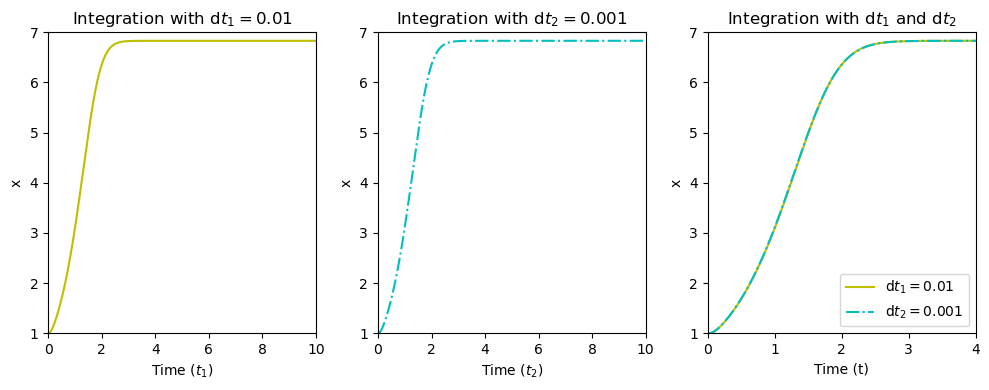

In [5]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10,4))
ax1.plot(t1, states1[:,0], '-', color = 'y')
ax1.set_ylim(1,7)
ax1.set_xlim(0,10)
ax1.set_xlabel("Time ($t_1$)")
ax1.set_ylabel("x")
ax1.set_title("Integration with d$t_1=0.01$")

ax2.plot(t2[::10], states2p[:, 0], '-.', color= 'c')
ax2.set_ylim(1,7)
ax2.set_xlim(0,10)
ax2.set_xlabel("Time ($t_2$)")
ax2.set_ylabel("x")
ax2.set_title("Integration with d$t_2=0.001$")

ax3.plot(t1, states1[:, 0],  '-', color = 'y', label="d$t_1 = 0.01$")
ax3.plot(t2[::10], states2p[:, 0], '-.', color= 'c', label= "d$t_2 = 0.001$")
ax3.set_ylim(1,7)
ax3.set_xlim(0,4)
ax3.set_xlabel("Time (t)")
ax3.set_ylabel("x")
ax3.set_title("Integration with d$t_1$ and d$t_2$")
ax3.legend(loc = "lower right")

plt.tight_layout()
plt.show()